<a href="https://colab.research.google.com/github/mattsmiths/biol470/blob/main/week11/EEG_processing_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np
import os

In [2]:
#@title Click to copy the class code repository
!git clone https://github.com/mattsmiths/biol470.git

Cloning into 'biol470'...
remote: Enumerating objects: 914, done.
remote: Counting objects: 100% (319/319), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 914 (delta 224), reused 229 (delta 162), pack-reused 595 (from 3)
Receiving objects: 100% (914/914), 934.07 MiB | 28.02 MiB/s, done.
Resolving deltas: 100% (382/382), done.
Updating files: 100% (356/356), done.


In [3]:
import glob
getFiles = glob.glob('/content/biol470/week11/2026_data/*.wav')
for ele in getFiles:
  print(ele)

/content/biol470/week11/2026_data/class_rec3_BYB_Recording_2026-03-26_12.30.55.wav
/content/biol470/week11/2026_data/class_rec4_BYB_Recording_2026-03-26_12.25.02.wav
/content/biol470/week11/2026_data/class_rec1_BYB_Recording_2026-03-26_12.00.41.wav
/content/biol470/week11/2026_data/class_rec2_BYB_Recording_2026-03-26_12.12.39.wav


In [16]:
audioPath1 = getFiles[0]#'/content/biol470/week11/2025_data/group_1/Yellow (POP) BYB_Recording_2025-03-27_12.22.09.wav'

In [ ]:
audioPath2 = '/content/biol470/week11/2025_data/group_1/Yellow (POP) BYB_Recording_2025-03-27_12.22.09.wav'

In [17]:
# Reading in the file
audio, sr = librosa.load(audioPath1,mono=False)  # Load audio file
print(len(audio)/sr)


232.80380952380952


In [ ]:
plt.figure()
plt.plot(audio,color=(0.3,0.3,0.3,0.5))
plt.title('Audio Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

In [ ]:
xsecs = np.arange(0,len(audio),sr)
print('The duration of the recording is: %s seconds'%len(xsecs))

The duration of the recording is: 40 seconds


In [ ]:
xsecs = np.arange(0,len(audio),(sr*5))

plt.figure()
plt.plot(audio,color=(0.3,0.3,0.3,0.5))
plt.title('Audio Signal')
plt.xlabel('Time (secs)')
plt.ylabel('Amplitude')

temp = np.arange(0,len(xsecs))*5

ll = plt.xticks(xsecs,temp)




In [ ]:
# Reading in the file 1
audio1, sr1 = librosa.load(audioPath1,mono=False)  # Load audio file
print(len(audio1)/sr1)

# Reading in the file 2
audio2, sr2 = librosa.load(audioPath2,mono=False)  # Load audio file
print(len(audio2)/sr2)


plt.figure(figsize=(10,5))

# for the first plot
plt.subplot(1,2,1)
xsecs1 = np.arange(0,len(audio1),(sr1*5))
plt.plot(audio1,color=(0.3,0.3,0.3,0.5))
plt.title('Audio Signal 1')
plt.xlabel('Time (secs)')
plt.ylabel('Amplitude')
temp = np.arange(0,len(xsecs))*5
ll = plt.xticks(xsecs,temp)

# for the second plot
plt.subplot(1,2,2)
xsecs2 = np.arange(0,len(audio2),(sr2*5))
plt.plot(audio2,color=(0.5,0.3,0.3,0.5))
plt.title('Audio Signal 2')
plt.xlabel('Time (secs)')
plt.ylabel('Amplitude')
temp = np.arange(0,len(xsecs2))*5
ll = plt.xticks(xsecs2,temp)

232.80380952380952
254.66190476190476


Text(0.5, 1.0, 'Comparing Amplitudes')

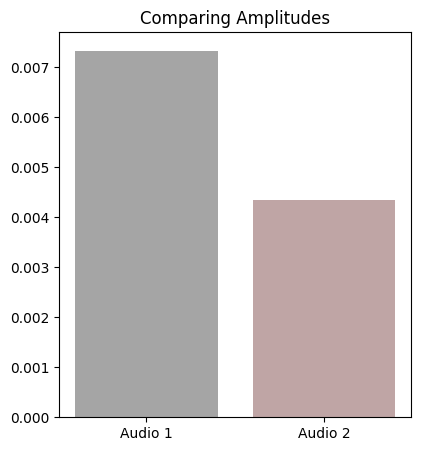

In [4]:
# Reading in the file 1
audio1, sr1 = librosa.load(getFiles[0],mono=False)  # Load audio file
print(len(audio1)/sr1)

# Reading in the file 2
audio2, sr2 = librosa.load(getFiles[1],mono=False)  # Load audio file
print(len(audio2)/sr2)


plt.figure(figsize=(10,5))

# for the first plot
plt.subplot(1,2,1)

# amplitude mean of audio 1
mean1 = np.mean(abs(audio1))
sem1 = np.std(abs(audio1))/np.sqrt(len(audio1))
plt.bar('Audio 1',mean1,color=(0.3,0.3,0.3,0.5))
plt.plot([0,0],[mean1-sem1,mean1+sem1],color=(0.2,0.2,0.2),linewidth=2)


# amplitude mean of audio 2
mean2 = np.mean(abs(audio2))
sem2 = np.std(abs(audio2))/np.sqrt(len(audio2))
plt.bar('Audio 2',mean2,color=(0.5,0.3,0.3,0.5))
plt.plot([1,1],[mean2-sem2,mean2+sem2],color=(0.2,0.2,0.2),linewidth=2)

plt.title('Comparing Amplitudes')



In [8]:
# Perform Fourier Transform to extract frequencies
# Apply Fast Fourier Transform (FFT) to the audio signal
fft_result = np.fft.fft(audio2)
fft_result = np.fft.fft(audio2)
fft_freq = np.fft.fftfreq(len(fft_result), 1/sr1)

# Only keep the positive frequencies
# your x label (what frequency)
positive_frequencies = fft_freq[:len(fft_freq)//2]

# the count of that frequency
positive_fft_result = np.abs(fft_result[:len(fft_result)//2])

In [11]:
positive_frequencies

array([0.00000000e+00, 3.92677500e-03, 7.85354999e-03, ...,
       1.10249863e+04, 1.10249902e+04, 1.10249941e+04])

Text(0.5, 0, 'Frequency (Hz)')

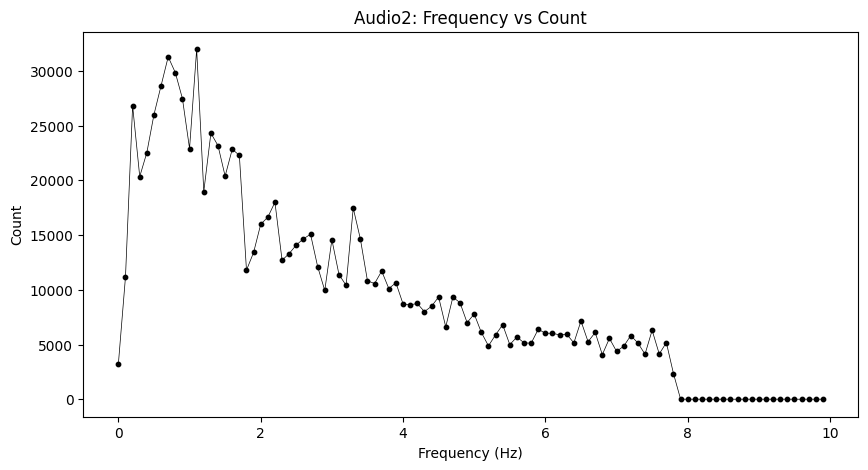

In [13]:
xx = []
yy = []
for ee in np.arange(0,10,0.1):
  temp = 0
  for ind,ele in enumerate(positive_frequencies[:2000]):
    if ele > ee and ele <= ee+0.1:
      temp+=positive_fft_result[ind]
  xx.append(ee)
  yy.append(int(temp))

plt.figure(figsize=(10,5))
#plt.bar(xx,yy,color=(0.65,0.65,0.65,0.8))
plt.plot(xx,yy,color=(0,0,0),linewidth=0.5)
plt.scatter(xx,yy,color=(0,0,0),s=10)
#ii = plt.xticks(np.arange(0,51,2))
plt.title('Audio2: Frequency vs Count')
plt.ylabel('Count')
plt.xlabel('Frequency (Hz)')

Text(0.5, 0, 'Frequency (Hz)')

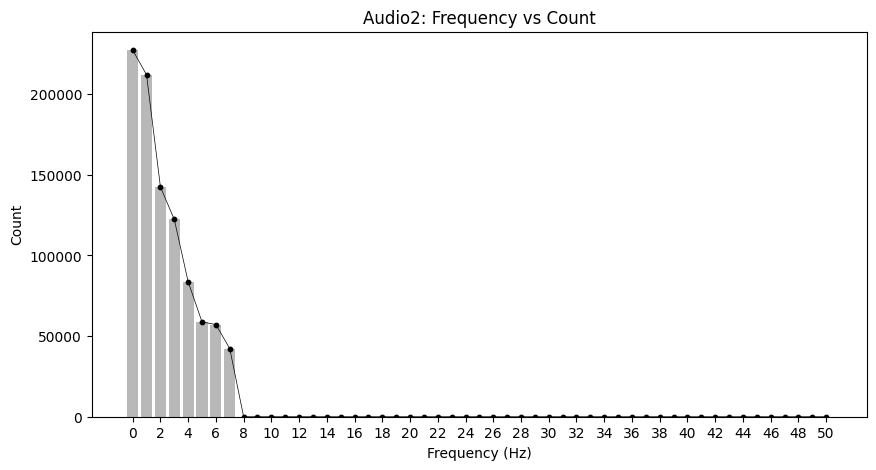

In [9]:
xx = []
yy = []
for ee in range(0,51):
  temp = 0
  for ind,ele in enumerate(positive_frequencies[:2000]):
    if ele > ee and ele <= ee+1:
      temp+=positive_fft_result[ind]
  xx.append(ee)
  yy.append(int(temp))

plt.figure(figsize=(10,5))
plt.bar(xx,yy,color=(0.65,0.65,0.65,0.8))
plt.plot(xx,yy,color=(0,0,0),linewidth=0.5)
plt.scatter(xx,yy,color=(0,0,0),s=10)
ii = plt.xticks(np.arange(0,51,2))
plt.title('Audio2: Frequency vs Count')
plt.ylabel('Count')
plt.xlabel('Frequency (Hz)')

Text(0.5, 0, 'Frequency (Hz)')

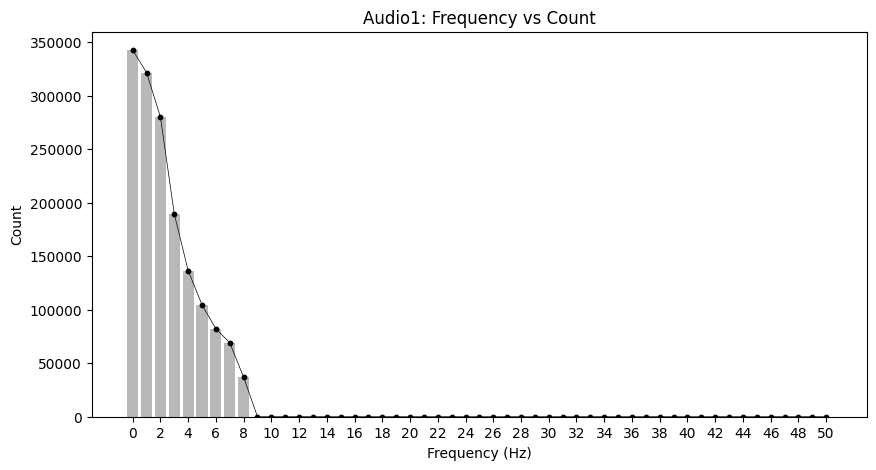

In [7]:
xx = []
yy = []
for ee in range(0,51):
  temp = 0
  for ind,ele in enumerate(positive_frequencies[:2000]):
    if ele > ee and ele <= ee+1:
      temp+=positive_fft_result[ind]
  xx.append(ee)
  yy.append(int(temp))

plt.figure(figsize=(10,5))
plt.bar(xx,yy,color=(0.65,0.65,0.65,0.8))
plt.plot(xx,yy,color=(0,0,0),linewidth=0.5)
plt.scatter(xx,yy,color=(0,0,0),s=10)
ii = plt.xticks(np.arange(0,51,2))
plt.title('Audio1: Frequency vs Count')
plt.ylabel('Count')
plt.xlabel('Frequency (Hz)')

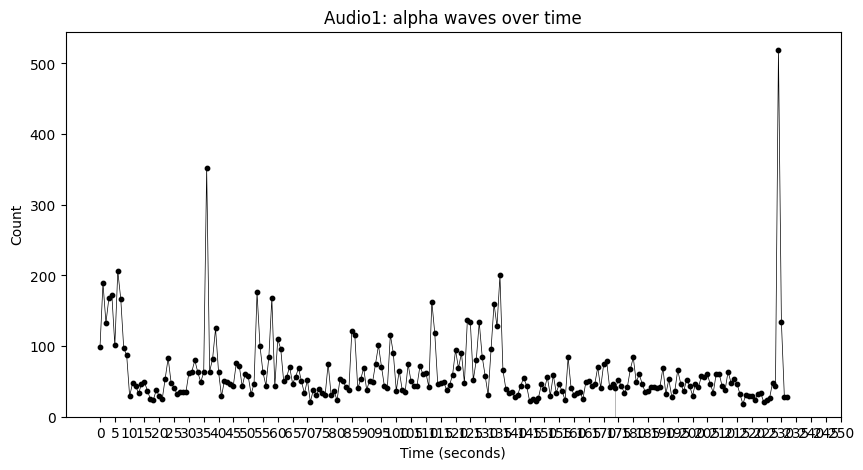

In [18]:
xx = []
yy = []

# alpha waves range
fMin = 8
fMax = 13



for secs in np.arange(0,len(audio1),sr):

  audioClip = audio1[secs:secs+sr]
  # Perform Fourier Transform to extract frequencies
  # Apply Fast Fourier Transform (FFT) to the audio signal
  fft_result = np.fft.fft(audioClip)
  fft_result = np.fft.fft(audioClip)
  fft_freq = np.fft.fftfreq(len(fft_result), 1/sr1)

  # Only keep the positive frequencies
  # your x label (what frequency)
  positive_frequencies = fft_freq[:len(fft_freq)//2]

  # the count of that frequency
  positive_fft_result = np.abs(fft_result[:len(fft_result)//2])

  temp = 0
  for ind,ele in enumerate(positive_frequencies[:2000]):
    if ele > fMin and ele <= fMax+1:
      temp+=positive_fft_result[ind]

  xx.append(secs+1)
  yy.append(int(temp))



plt.figure(figsize=(10,5))
plt.bar(xx,yy,color=(0.65,0.65,0.65,0.8))
plt.plot(xx,yy,color=(0,0,0),linewidth=0.5)
plt.scatter(xx,yy,color=(0,0,0),s=10)
#ii = plt.xticks(np.arange(0,51,2))
plt.title('Audio1: alpha waves over time')
plt.ylabel('Count')
plt.xlabel('Time (seconds)')

xsecs2 = np.arange(0,len(audio2),(sr2*5))
temp = np.arange(0,len(xsecs2))*5
ll = plt.xticks(xsecs2,temp)

In [ ]:
# matt mix annotations
# clair de luna = 13.1 24.1 (24 - 45)
# bb = 28 -35 (54: 1:08)
# fela = 42 - 49 (1:22 - 1:36)
# dtwon = 51 -55 (1:40 - 1:48)
# 61 - 65 (2 - 2:08)
# 65 - 71 (2:08 - 2:17)
# 73 - 82 (2:24 - 2:43)